In [1]:
# Generating ground truth

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [3]:

# Mackey–Glass parameters
a, b, n = 0.2, 0.1, 10
tau, dt = 17.0, 0.1
total_points = 150001
history_length = int(tau / dt)

def Mackey_Glass(xt, xtau, a=0.2, b=0.1, n=10):
    return -b * xt + a * xtau / (1 + xtau**n)

def Mackey_Glass_rk4(xt, xtau, a=0.2, b=0.1, n=10, h=0.1):
    k1 = h * Mackey_Glass(xt, xtau, a, b, n)
    k2 = h * Mackey_Glass(xt + 0.5 * k1, xtau, a, b, n)
    k3 = h * Mackey_Glass(xt + 0.5 * k2, xtau, a, b, n)
    k4 = h * Mackey_Glass(xt + k3, xtau, a, b, n)
    return xt + (k1 + 2*k2 + 2*k3 + k4) / 6.0

# Initialize history buffer with random values
np.random.seed(2025)
buffer = 1.2 + np.random.rand(history_length)

# Full series length including history
series_length = total_points + history_length
x = np.zeros(series_length)

# Fill initial delay values
x[:history_length] = buffer

# Integrate
for t in range(history_length, series_length - 1):
    xt = x[t]
    xtau = x[t - history_length]
    x[t + 1] = Mackey_Glass_rk4(xt, xtau, a, b, n, h=dt)

# Extract the actual generated time series (after initial history)
mg_series = x[history_length:].reshape(1, -1)

print(mg_series.shape)  # should print (1, total_points)

mg_series_sampled = mg_series[:,::10]


(1, 150001)


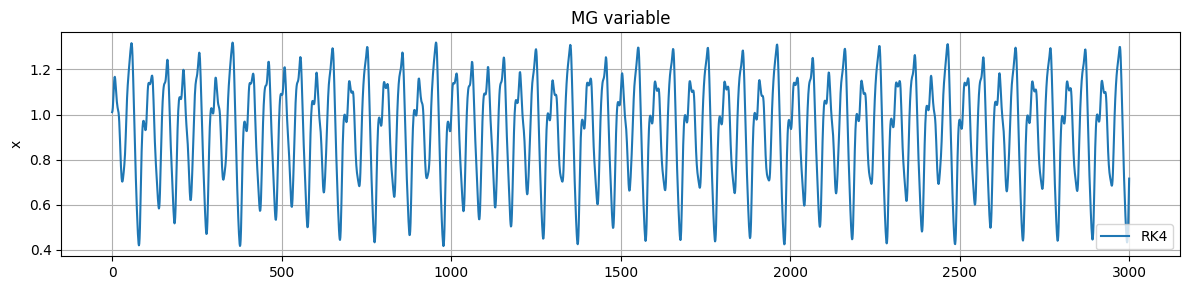

In [4]:

np.save("ground_truth", mg_series_sampled)
Lorenz63data = mg_series_sampled.T

# ---------------------------
# Visualization
# ---------------------------
variables = ['x']
plt.figure(figsize=(12, 3))
for i in range(1):
    plt.subplot(1, 1, i + 1)
    plt.plot(mg_series_sampled[i, 1000:4000], label='RK4', color='C0')
    plt.ylabel(variables[i])
    plt.grid(True)
    if i == 0:
        plt.title("MG variable")
    if i == 2:
        plt.xlabel('Time')
    plt.legend()
plt.tight_layout()
plt.savefig("MG.png", format='png', dpi=600, bbox_inches='tight')
plt.show()